# 8. AIND Ephys Processing QC

Run [aind-ephys-processing-qc](https://github.com/AllenNeuralDynamics/aind-ephys-processing-qc/tree/main/code) on the layout produced by `07_aind_ephys_results_collector.ipynb`.

The capsule loads the raw recording (via the dispatch `job_*.json`), the preprocessed binary (`preprocessed/<name>.json`), and the postprocessed `SortingAnalyzer` (`postprocessed/<name>.zarr`), then writes per-recording QC figures + an aind-data-schema `quality_control.json` (an `aind_data_schema.core.quality_control.QualityControl` document) into `../results/`.

We pass `--no-event-metrics` because there's no HARP behavior data attached.

## Imports and deps

In [1]:
import json
import shutil
import subprocess
import sys
from pathlib import Path

In [2]:
subprocess.run(
    [
        "uv", "pip", "install", "--python", sys.executable,
        "aind-data-schema", "aind-qcportal-schema", "matplotlib",
    ],
    check=True,
)

Using Python 3.12.9 environment at: /Users/james/Documents/obi/code/obi-main/obi-one/.venv
Resolved 26 packages in 9ms
Uninstalled 2 packages in 6ms
Installed 2 packages in 3ms
 - pydantic==2.12.5
 + pydantic==2.11.10
 - pydantic-core==2.41.5
 + pydantic-core==2.33.2


CompletedProcess(args=['uv', 'pip', 'install', '--python', '/Users/james/Documents/obi/code/obi-main/obi-one/.venv/bin/python', 'aind-data-schema', 'aind-qcportal-schema', 'matplotlib'], returncode=0)

## Clone the capsule and seed `data/`

The capsule expects the collector's output layout flat in `data/`: `preprocessed/<name>.json`, `postprocessed/<name>.zarr`, `processing.json`, plus the dispatch `job_*.json` and an `ecephys_*` session folder.

In [3]:
qc_repo = Path("/tmp/aind-ephys-processing-qc")
if not qc_repo.exists():
    subprocess.run(
        [
            "git", "clone", "--depth=1",
            "https://github.com/AllenNeuralDynamics/aind-ephys-processing-qc.git",
            str(qc_repo),
        ],
        check=True,
    )

data_dir = qc_repo / "data"
results_dir = qc_repo / "results"
data_dir.mkdir(exist_ok=True)
results_dir.mkdir(exist_ok=True)

for stale in list(data_dir.iterdir()) + list(results_dir.iterdir()):
    shutil.rmtree(stale) if stale.is_dir() else stale.unlink()

collected = Path.cwd() / "output/07_collected_results"
output/01_dispatch_results = Path.cwd() / "output/01_dispatch_results"
assert collected.exists(), "Run 07_aind_ephys_results_collector.ipynb first."

for entry in collected.iterdir():
    dest = data_dir / entry.name
    shutil.copytree(entry, dest) if entry.is_dir() else shutil.copy2(entry, dest)

for entry in output/01_dispatch_results.iterdir():
    dest = data_dir / entry.name
    if not dest.exists():
        shutil.copy2(entry, dest)

session_folder = data_dir / "ecephys_toy"
session_folder.mkdir(exist_ok=True)
(session_folder / "subject.json").write_text(json.dumps({"subject_id": "000000"}))

print("Seeded data dir:")
for p in sorted(data_dir.iterdir()):
    print(" ", p.name)

# Patch qc_utils.py for spikeinterface API drift:
#  - bandpass_filter freq_min=0.1 now needs ignore_low_freq_error=True
#  - template_metrics 'half_width' was renamed to 'trough_half_width'
qc_utils_py = qc_repo / "code" / "qc_utils.py"
src = qc_utils_py.read_text()
patched = src.replace(
    "spre.bandpass_filter(recording, freq_min=0.1, freq_max=freq_lfp)",
    "spre.bandpass_filter(recording, freq_min=0.1, freq_max=freq_lfp, ignore_low_freq_error=True)",
)
patched = patched.replace("template_metrics['half_width']", "template_metrics['trough_half_width']")
if patched != src:
    qc_utils_py.write_text(patched)
    print("Patched qc_utils.py")

Seeded data dir:
  curated
  data_description.json
  ecephys_toy
  job_0.json
  postprocessed
  preprocessed
  processing.json
  spikesorted
  subject.json
  visualization
  visualization_output.json


## Run the QC capsule

In [4]:
argv = [
    "python", "-u", "run_capsule.py",
    "--no-event-metrics",
    "--min-duration-allow-failed", "0",
]
print("Running:", " ".join(argv))
result = subprocess.run(
    argv,
    cwd=qc_repo / "code",
    capture_output=True,
    text=True,
    check=False,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:\n", result.stderr)
    raise RuntimeError(f"processing-qc run failed with code {result.returncode}")

Running: python -u run_capsule.py --no-event-metrics --min-duration-allow-failed 0


Running Ephys QC with the following parameters:
	COMPUTE EVENT METRICS: True
	MIN DURATION ALLOW FAILED: 0.0
Found 1 JSON job files
Events from HARP not found. Trigger event metrics will not be generated.
Recording block0_None_recording1
Failed to load bad channel labels for block0_None_recording1
Generating RAW DATA metrics
Generating PSD metrics
Generating NOISE metrics
Generating SATURATION metric
	Saturation threshold for block0_None_recording1 not available. Cannot generate saturation metrics.
	Motion not found for block0_None_recording1
Generating UNIT YIELD metric
Smooting amplitudes failed.
Smooting firing rates failed.
Generating FIRING RATE metric
EPHYS QC time: 3.45s



## Copy outputs next to the notebook

In [5]:
local_results_dir = Path.cwd() / "output/08_qc_results"
local_results_dir.parent.mkdir(parents=True, exist_ok=True)
if local_results_dir.exists():
    shutil.rmtree(local_results_dir)
shutil.copytree(results_dir, local_results_dir)

for p in sorted(local_results_dir.rglob("*")):
    rel = p.relative_to(local_results_dir)
    kind = "dir" if p.is_dir() else f"{p.stat().st_size} bytes"
    print(f"  {rel}  ({kind})")

  quality_control_block0_None_recording1  (dir)
  quality_control_block0_None_recording1/firing_rate.png  (80291 bytes)
  quality_control_block0_None_recording1/psd.png  (309323 bytes)
  quality_control_block0_None_recording1/rms.png  (135541 bytes)
  quality_control_block0_None_recording1/traces_raw.png  (415823 bytes)
  quality_control_block0_None_recording1/unit_yield.png  (333995 bytes)
  quality_control_block0_None_recording1.json  (6544 bytes)


## Inspect the QualityControl document and figures

==== quality_control_block0_None_recording1.json ====
  schema_version: 2.4.1
  Total metrics: 5
      Raw data  Raw data block0_None_recording1
      Raw data  PSD block0_None_recording1
      Raw data  RMS block0_None_recording1
    Processing  Unit Metrics Yield - block0_None_recording1
    Processing  Firing rate - block0_None_recording1

Generated 5 figure(s):
  quality_control_block0_None_recording1/firing_rate.png


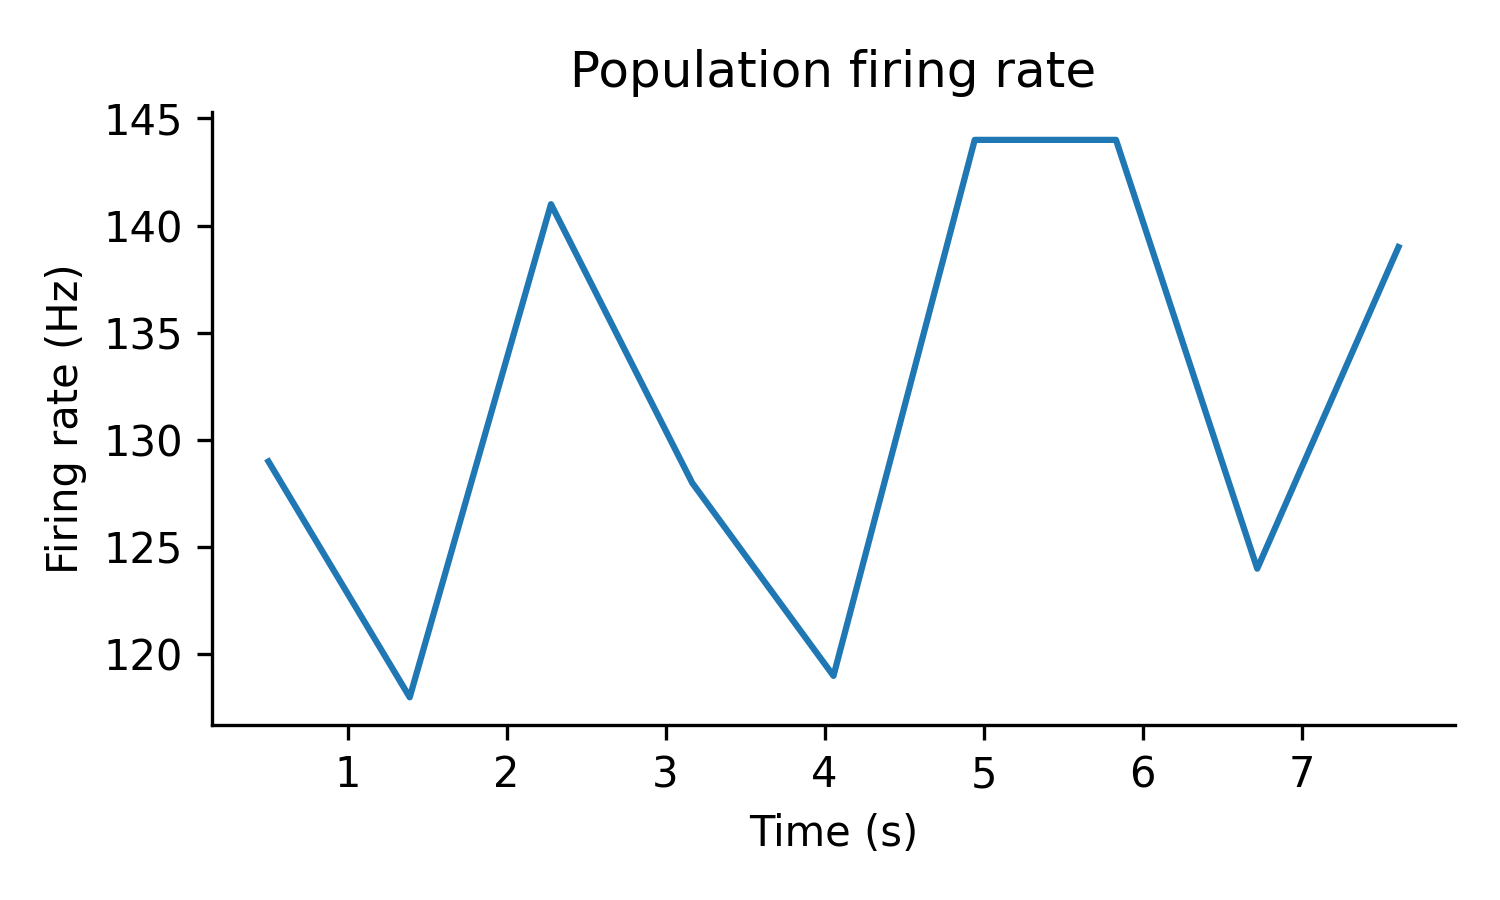

  quality_control_block0_None_recording1/psd.png


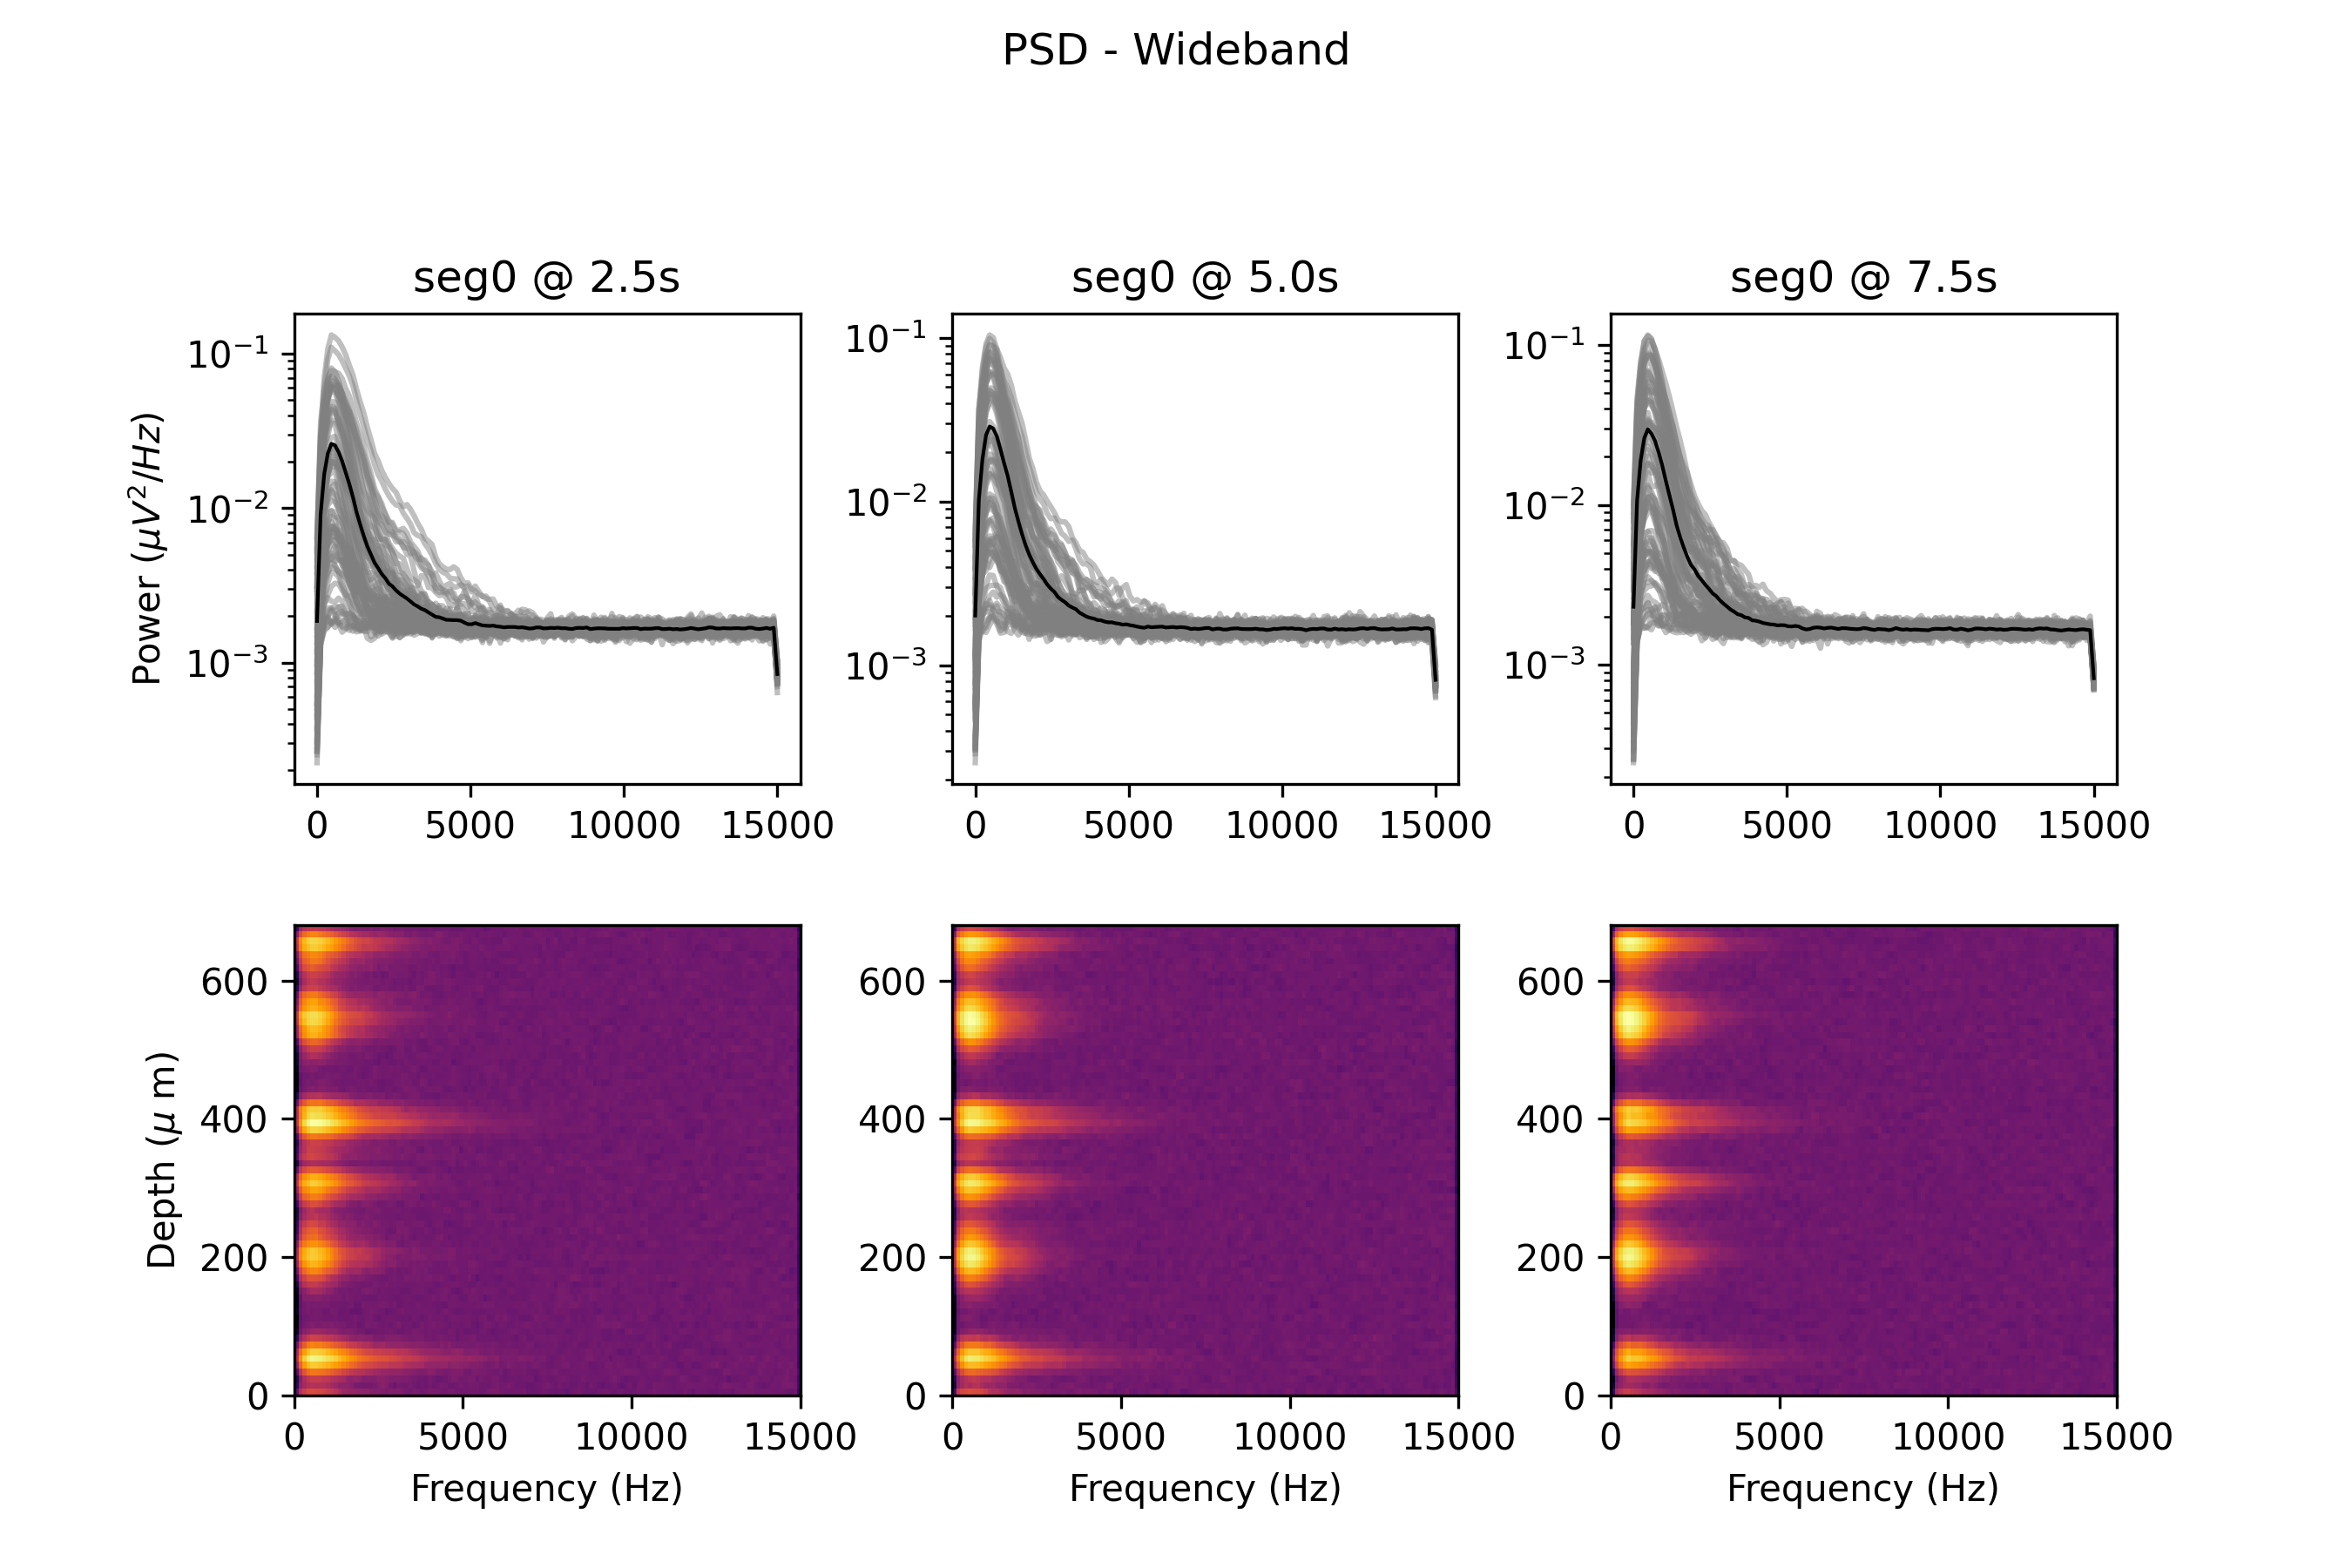

  quality_control_block0_None_recording1/rms.png


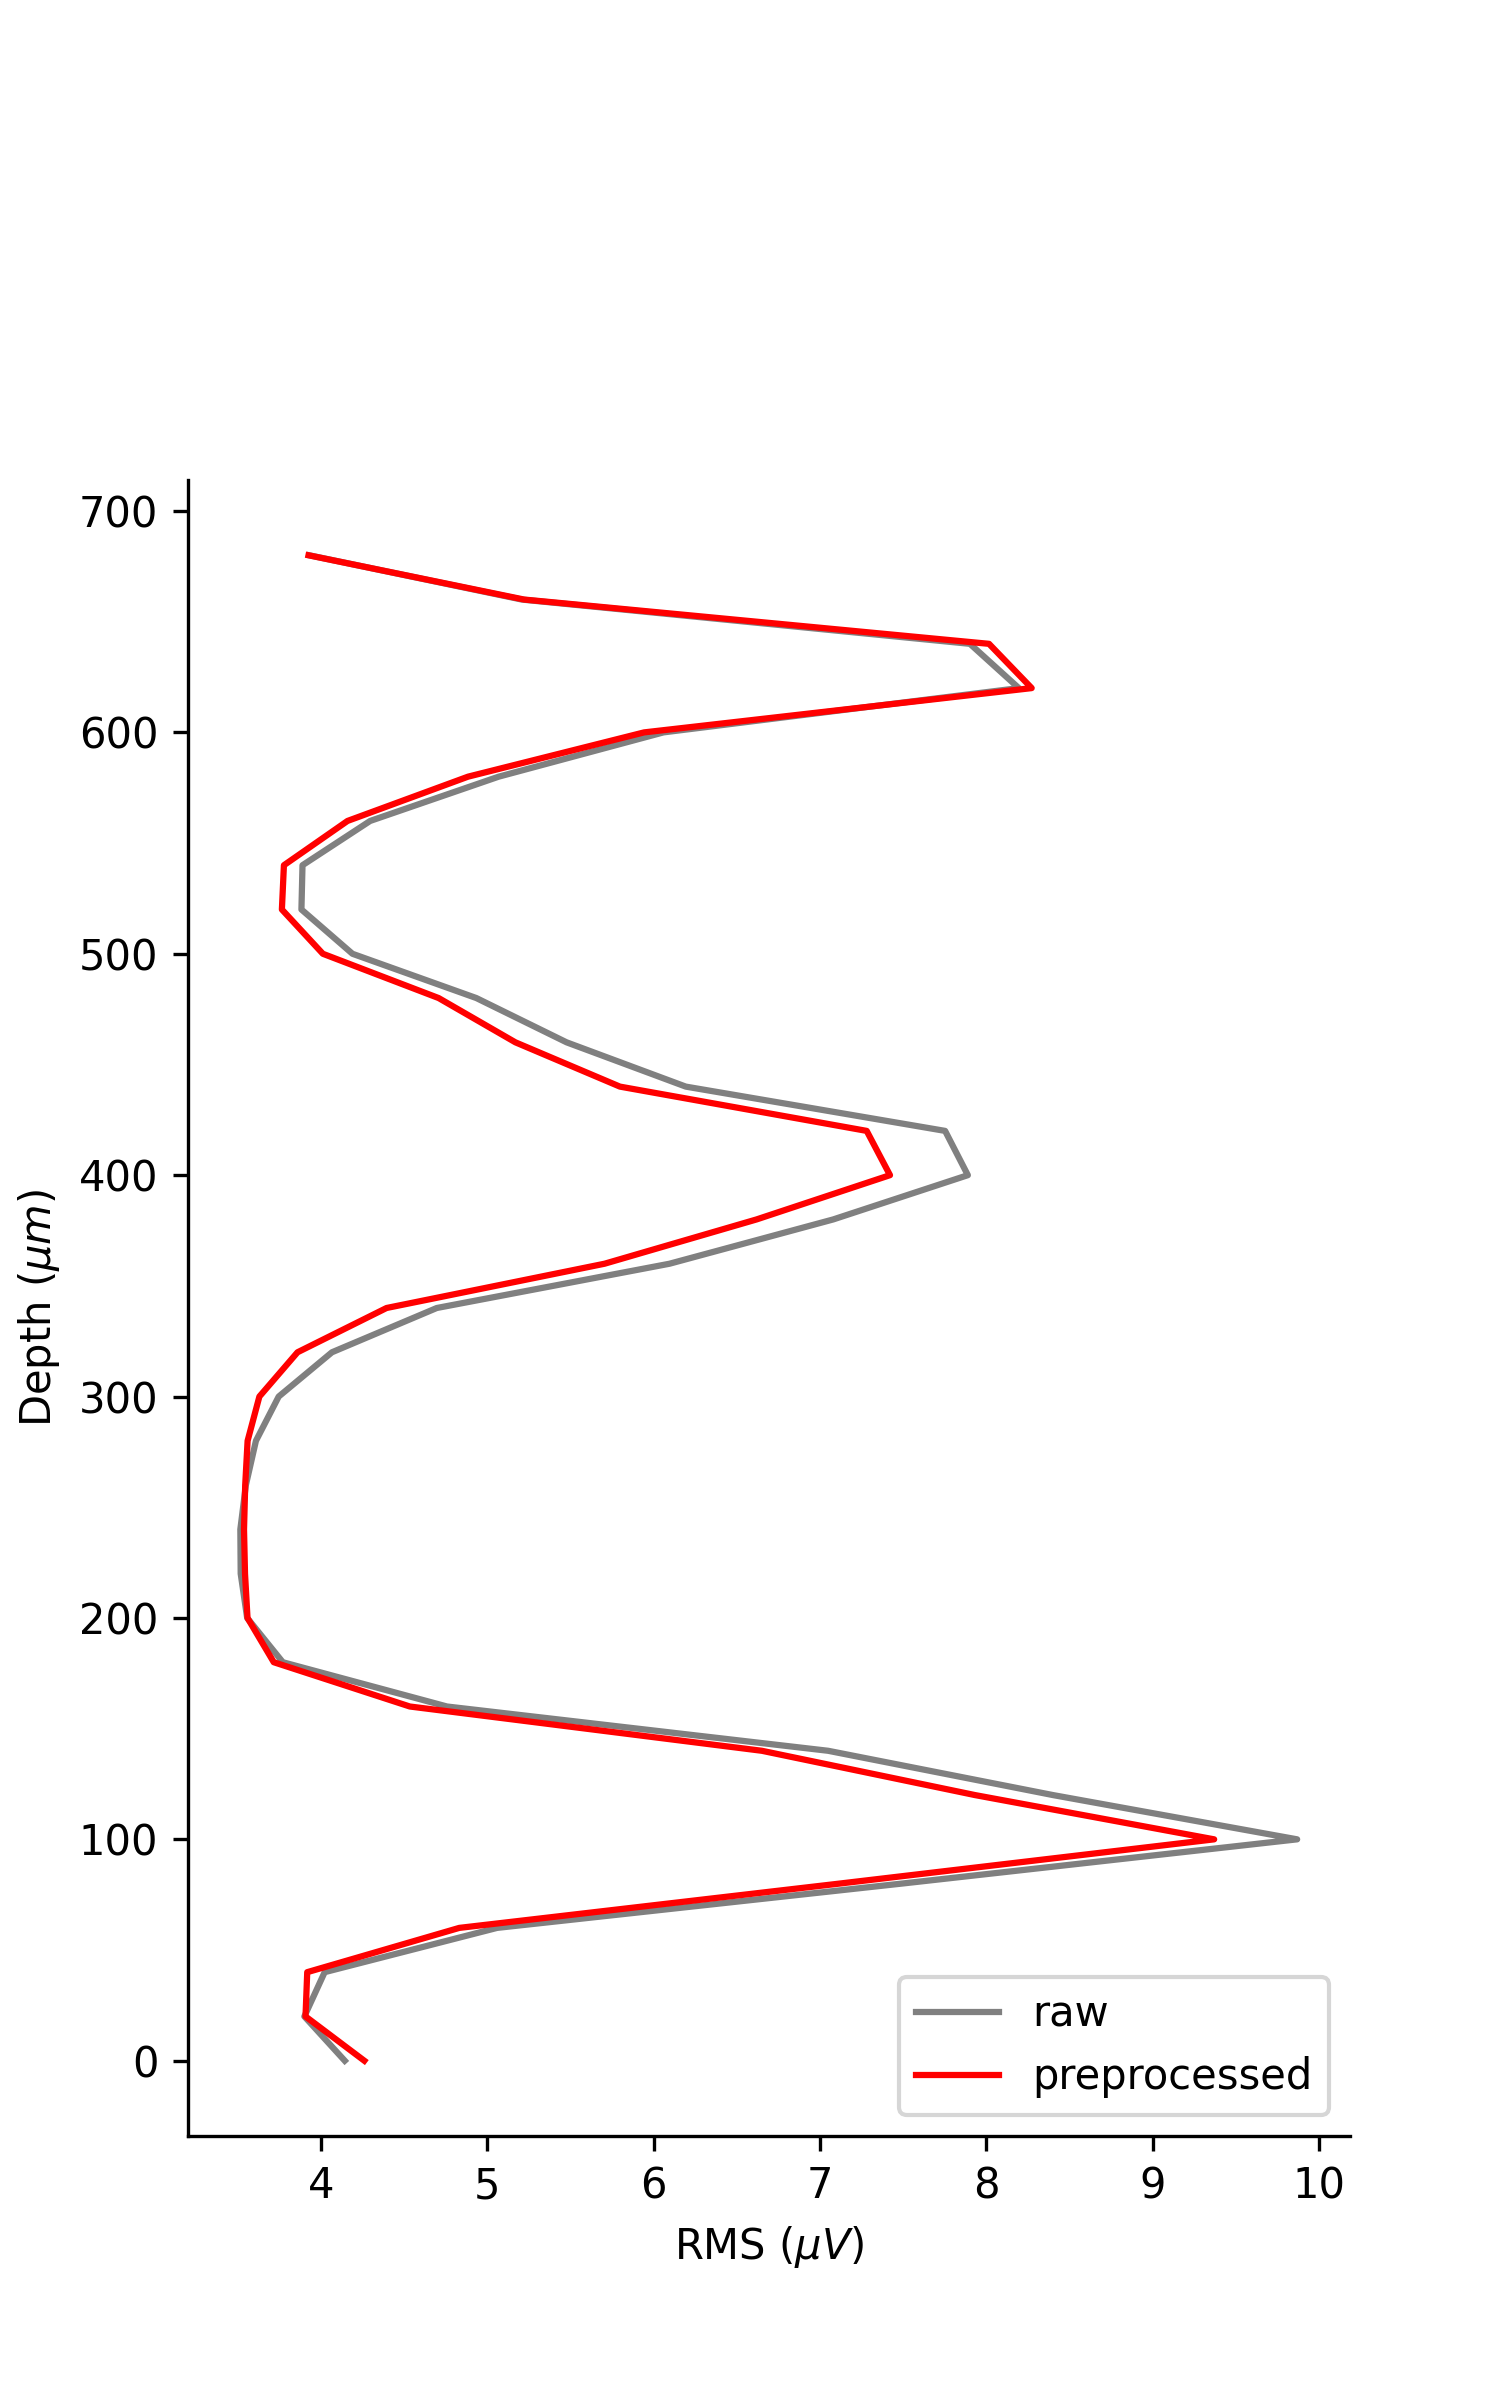

  quality_control_block0_None_recording1/traces_raw.png


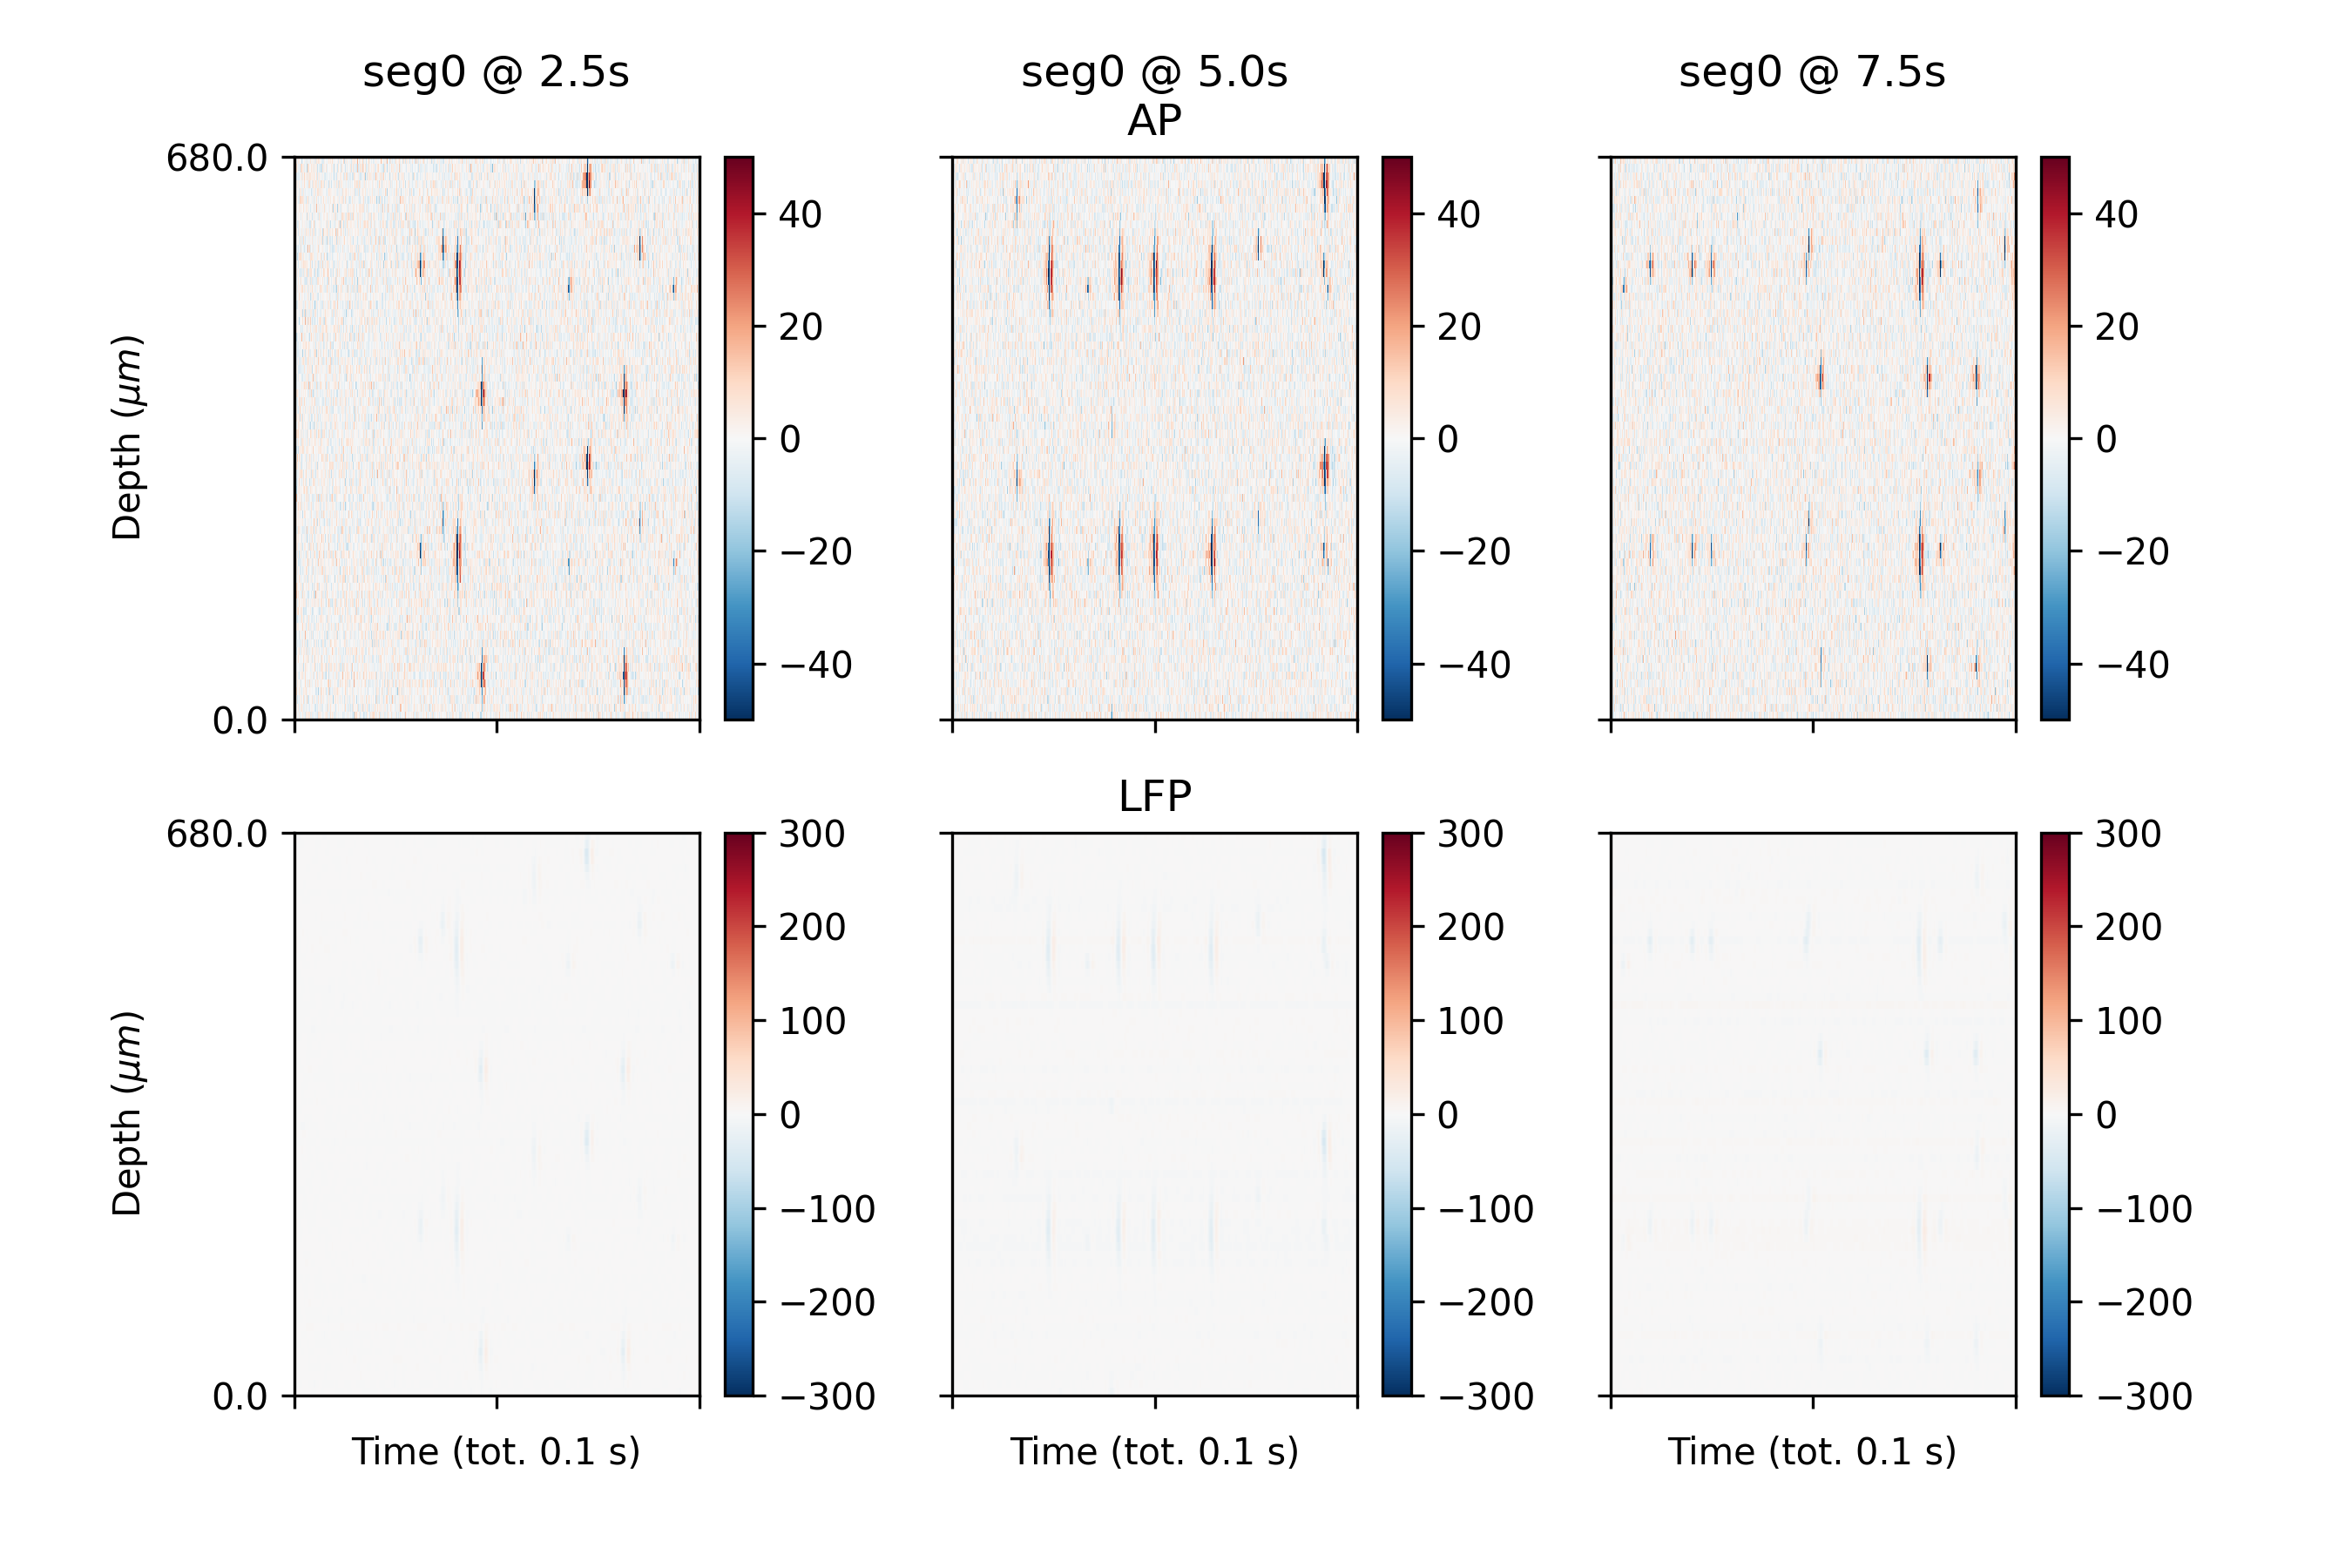

  quality_control_block0_None_recording1/unit_yield.png


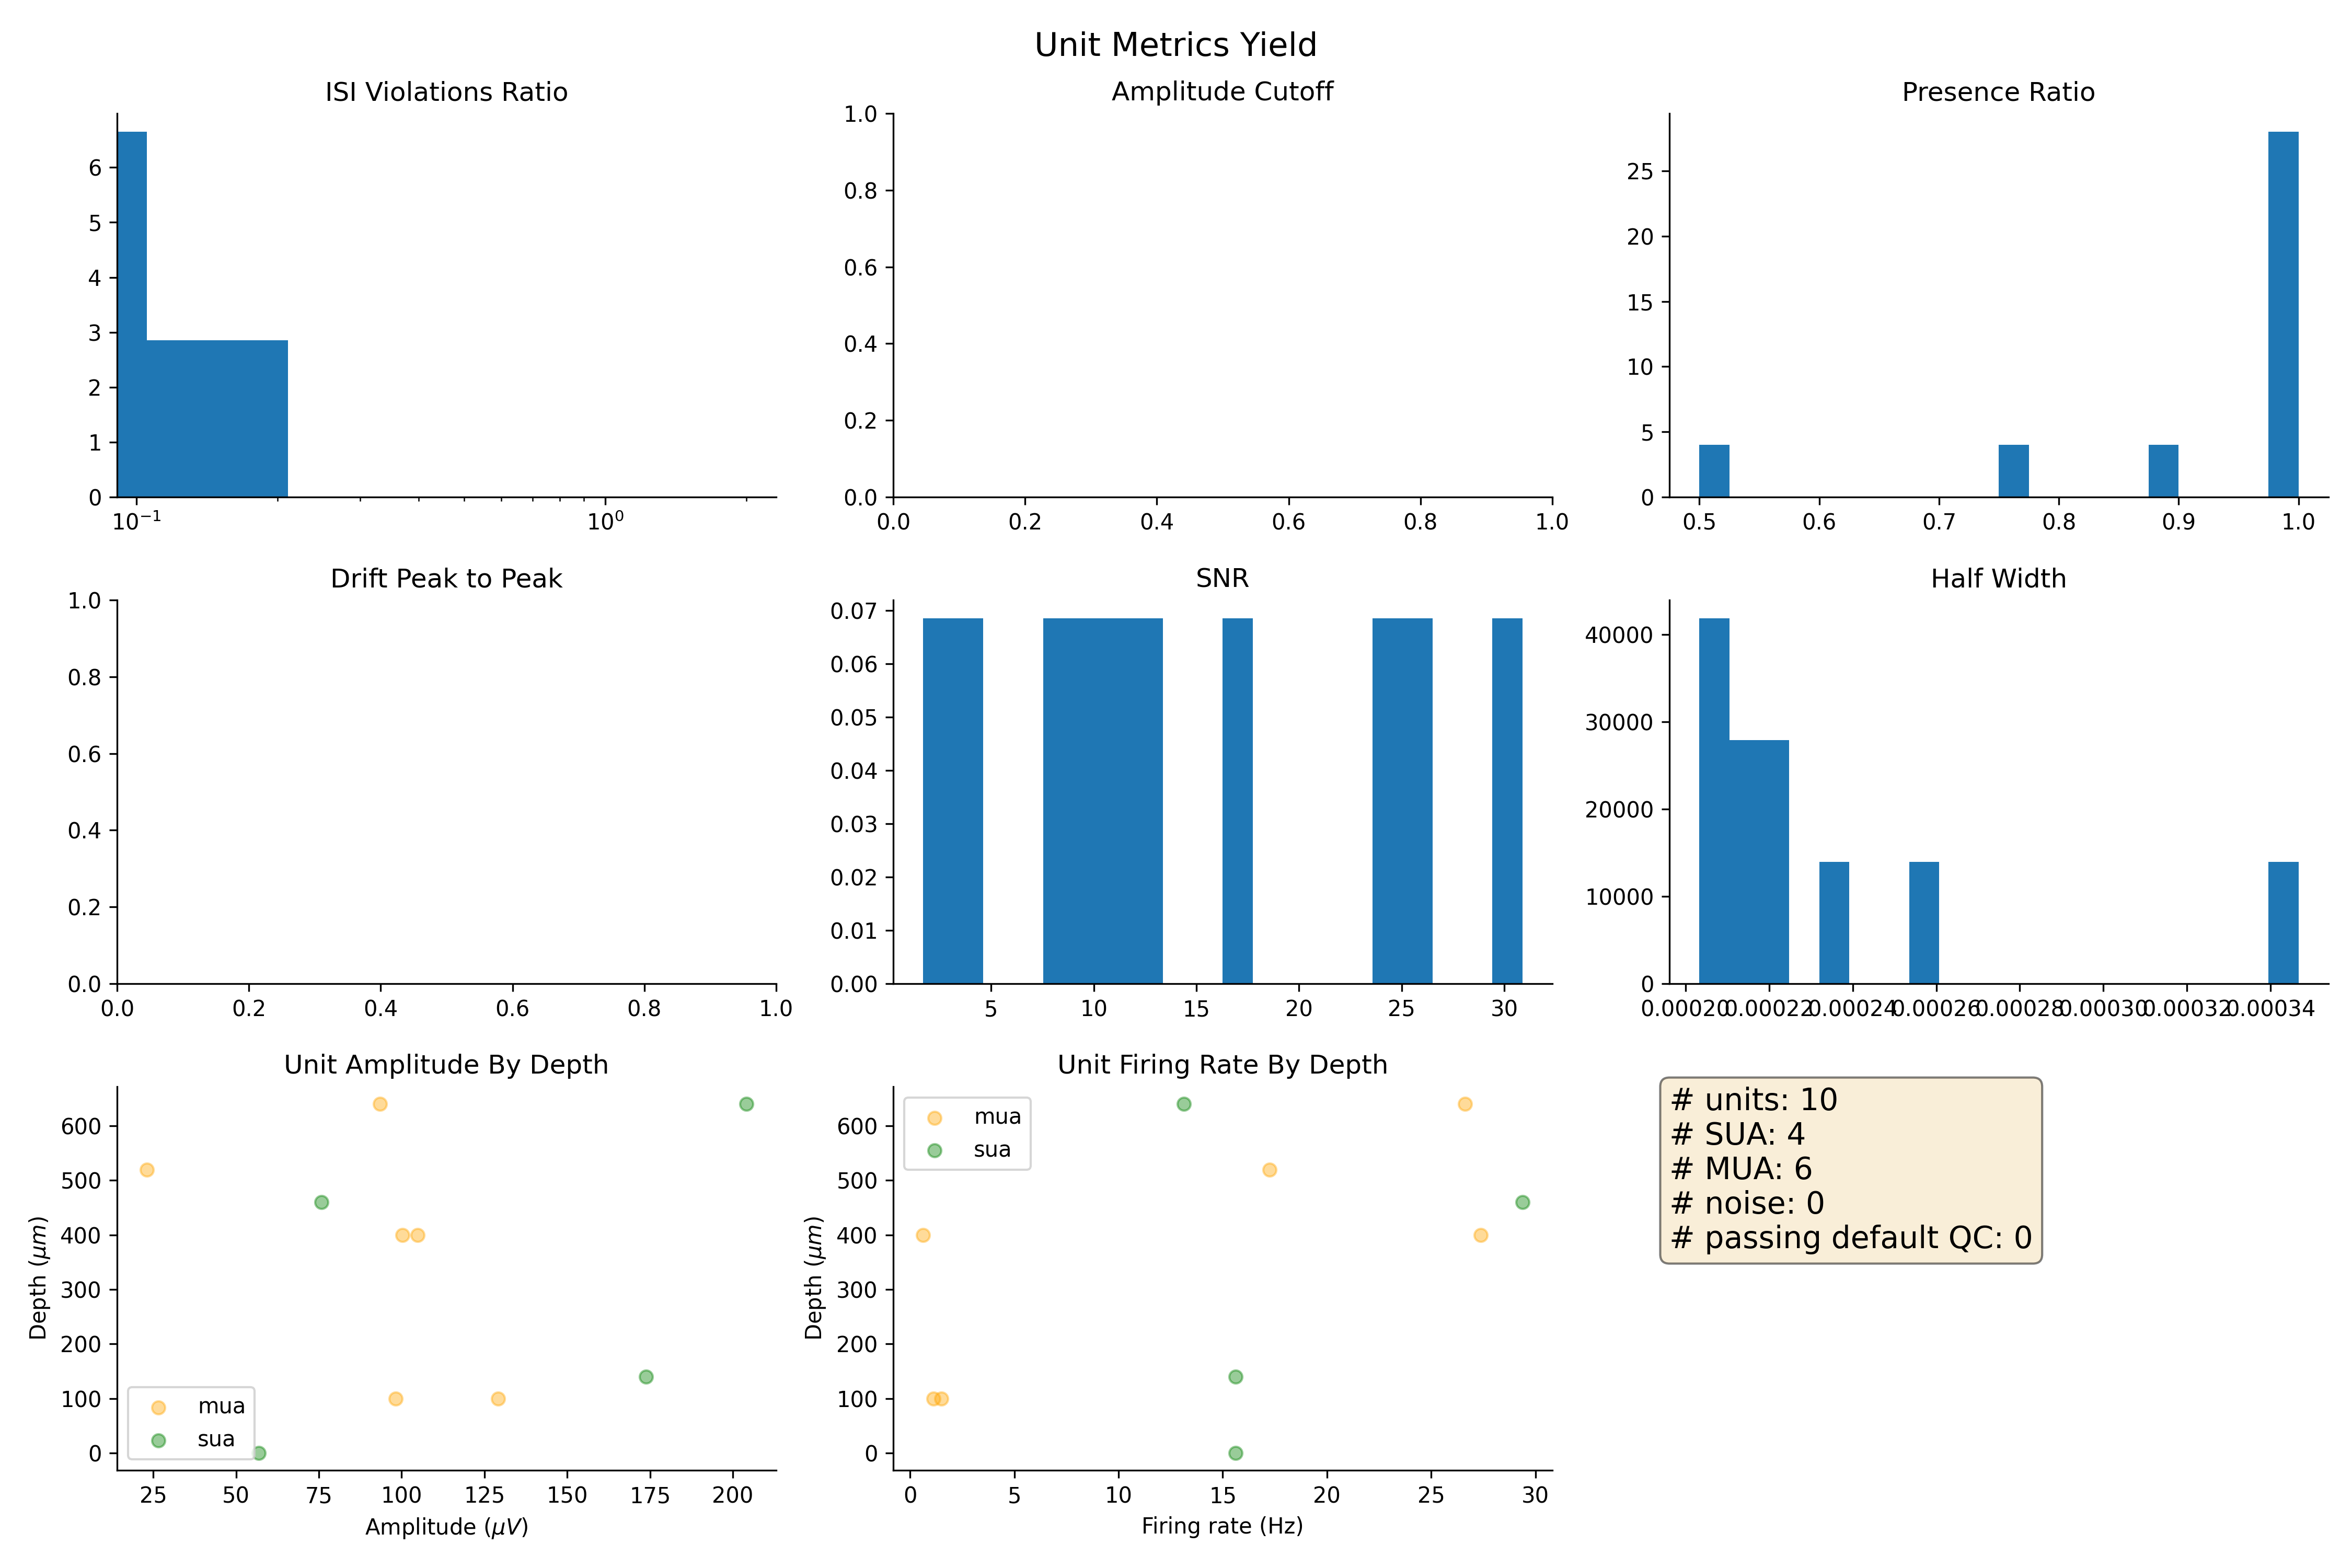

In [6]:
from IPython.display import Image, display

qc_files = sorted(local_results_dir.glob("quality_control_*.json"))
for qc_path in qc_files:
    print(f"==== {qc_path.name} ====")
    qc = json.loads(qc_path.read_text())
    print("  schema_version:", qc.get("schema_version"))
    metrics = qc.get("metrics", [])
    print(f"  Total metrics: {len(metrics)}")
    for m in metrics:
        print(f"    {m.get('stage'):>10}  {m.get('name')}")
    print()

pngs = sorted(local_results_dir.rglob("*.png"))
print(f"Generated {len(pngs)} figure(s):")
for p in pngs:
    print(" ", p.relative_to(local_results_dir))
    display(Image(filename=str(p)))